In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List
import os
import glob

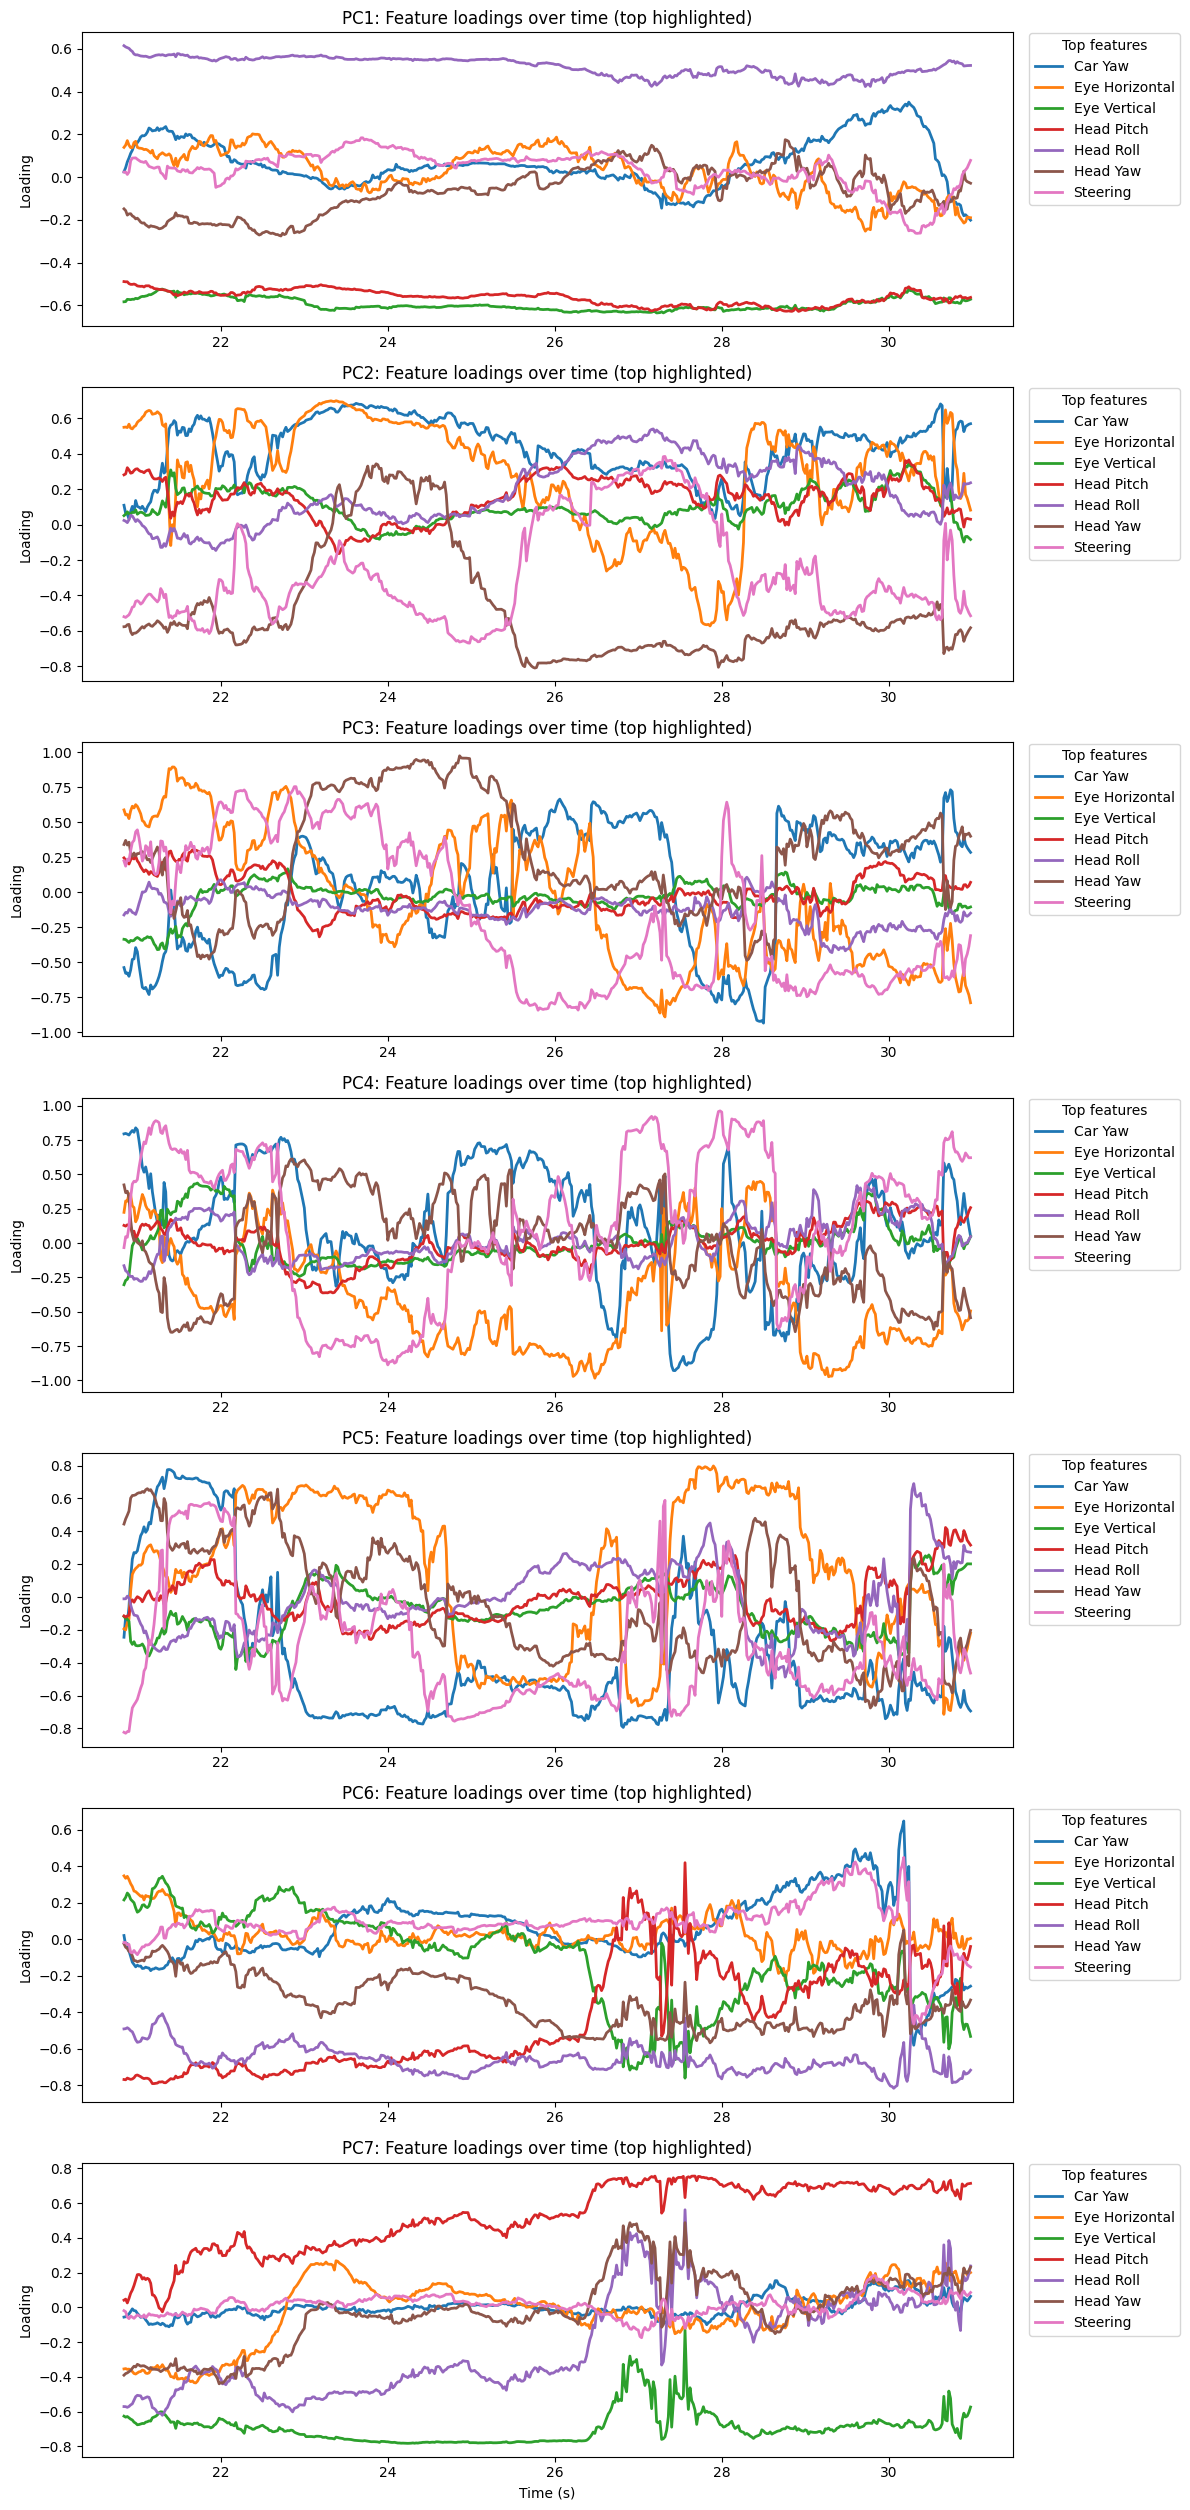

In [23]:
# =========================
# Feature-aware PCA visuals
# =========================
# This cell builds a tidy long table that retains `Features` and adds
# per-feature contributions, then renders several complementary views:
#   1) Heatmaps of signed loadings (Features x Time) per PC
#   2) Heatmaps of percent contributions (non-negative) per PC
#   3) Top-K stacked area contributions for a chosen PC
#   4) Small-multiples line plots with top features highlighted
#   5) Grouped contributions over time (Eye / Head / Steering / Other)

def _find_pc_columns(df: pd.DataFrame) -> List[str]:
    return [c for c in df.columns if isinstance(c, str) and c.startswith('PC')]


def _load_components_wide_from_memory_or_disk() -> pd.DataFrame:
    """Return wide components with columns ['Time','Event'|'EventName','Features','PC1', ...].
    Prefers in-memory variables; falls back to the most recent CSV under results/components/."""
    # Prefer in-memory objects if any contain Features + PC columns
    for var_name in ['components_df', 'components_wide', 'components_full', 'components_features', 'components_raw']:
        if var_name in globals():
            obj = globals()[var_name]
            if isinstance(obj, pd.DataFrame):
                if 'Features' in obj.columns and len(_find_pc_columns(obj)) > 0:
                    return obj.copy()
    # Otherwise search results/components recursively
    base = Path('results/components')
    candidates = sorted(base.rglob('components_*.csv'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError("No components CSV with 'Features' and PC columns found under results/components/.")
    df = pd.read_csv(candidates[0])
    return df


def _align_pc_signs_over_time(wide_df: pd.DataFrame, pc_cols: List[str], time_col: str = 'Time', feature_col: str = 'Features') -> pd.DataFrame:
    """Align signs to avoid arbitrary flips across time using consecutive dot products per PC."""
    if time_col not in wide_df.columns:
        return wide_df.copy()
    aligned_blocks = []
    previous_vectors: dict[str, np.ndarray | None] = {pc: None for pc in pc_cols}
    # Deterministic ordering so dot products are meaningful
    for t, block in wide_df.groupby(time_col, sort=True):
        block_sorted = block.sort_values(feature_col).copy()
        for pc in pc_cols:
            v = block_sorted[pc].to_numpy()
            prev = previous_vectors[pc]
            if prev is not None and np.dot(prev, v) < 0:
                block_sorted[pc] = -block_sorted[pc]
                v = -v
            previous_vectors[pc] = v
        aligned_blocks.append(block_sorted)
    return pd.concat(aligned_blocks, ignore_index=True)


def _feature_group_from_name(name: str) -> str:
    s = str(name).lower()
    if 'eye' in s:
        return 'Eye'
    if 'nose' in s or 'head' in s:
        return 'Head'
    if 'steer' in s:
        return 'Steering'
    return 'Other'


def _get_variance_long_if_available() -> pd.DataFrame | None:
    """Return long variance ratios with columns ['Time','PC','explained_variance_ratio'] if available."""
    if 'variances_df' not in globals():
        return None
    vdf = globals()['variances_df']
    if not isinstance(vdf, pd.DataFrame):
        return None
    cols = set(vdf.columns)
    # Already long
    if {'Time', 'PCs', 'pca_value'}.issubset(cols):
        out = vdf.rename(columns={'PCs': 'PC', 'pca_value': 'explained_variance_ratio'})
        return out[['Time', 'PC', 'explained_variance_ratio']].copy()
    # Wide -> melt
    pc_cols = _find_pc_columns(vdf)
    if {'Time'}.issubset(cols) and len(pc_cols) > 0:
        out = vdf.melt(id_vars=['Time'], value_vars=pc_cols, var_name='PC', value_name='explained_variance_ratio')
        return out
    return None


# 1) Acquire wide components with Features and PCs
_components_wide = _load_components_wide_from_memory_or_disk()
pc_cols = _find_pc_columns(_components_wide)
# Normalize event column name
if 'Event' not in _components_wide.columns and 'EventName' in _components_wide.columns:
    _components_wide = _components_wide.rename(columns={'EventName': 'Event'})

# 2) Align signs for stability across time
_components_wide = _align_pc_signs_over_time(_components_wide, pc_cols)

# 3) Long format with loadings and derived contributions
components_long_vis = _components_wide.melt(
    id_vars=['Time', 'Event', 'Features'], value_vars=pc_cols,
    var_name='PC', value_name='loading'
)
components_long_vis['abs_loading'] = components_long_vis['loading'].abs()
components_long_vis['contribution'] = components_long_vis['loading'] ** 2
components_long_vis['group'] = components_long_vis['Features'].apply(_feature_group_from_name)

# Normalize to percent contribution within each Time x Event x PC
sum_contrib = components_long_vis.groupby(['Time', 'Event', 'PC'])['contribution'].transform('sum')
components_long_vis['pct_contribution'] = np.where(sum_contrib > 0, components_long_vis['contribution'] / sum_contrib, 0.0)

# Optionally weight by explained variance ratio if available
var_long = _get_variance_long_if_available()
# Ensure comparable numeric dtype for 'Time' prior to merging
components_long_vis['Time'] = pd.to_numeric(components_long_vis['Time'], errors='coerce')
if var_long is not None:
    var_long = var_long.copy()
    var_long['Time'] = pd.to_numeric(var_long['Time'], errors='coerce')
    components_long_vis = components_long_vis.merge(var_long, on=['Time', 'PC'], how='left')
    components_long_vis['weighted_contribution'] = components_long_vis['pct_contribution'] * components_long_vis['explained_variance_ratio']
else:
    components_long_vis['explained_variance_ratio'] = np.nan
    components_long_vis['weighted_contribution'] = np.nan

smoothing = False          # enable/disable
smoothing_method = 'rolling'  # or 'ewm'
smoothing_window = 25      # frames; adjust to your sampling rate
smoothing_alpha = 0.25    # only for 'ewm'

# ---- Optional smoothing of loadings/contributions before visualization ----
# Control with globals in the notebook: set `smoothing=True` to enable.
smoothing = bool(globals().get('smoothing', False))
smoothing_method = str(globals().get('smoothing_method', 'rolling'))  # 'rolling' or 'ewm'
smoothing_window = int(globals().get('smoothing_window', 9))     # e.g., 7–15 frames
smoothing_alpha = float(globals().get('smoothing_alpha', 0.25))       # for EWM


if smoothing:
    # Avoid NaN propagation when smoothing weighted contribution
    components_long_vis['weighted_contribution'] = components_long_vis['weighted_contribution'].fillna(0.0)

    def _smooth_group(g: pd.DataFrame) -> pd.DataFrame:
        g = g.sort_values('Time').copy()
        if smoothing_method == 'rolling':
            g['loading_smooth'] = g['loading'].rolling(smoothing_window, center=True, min_periods=1).mean()
            g['pct_contribution_smooth'] = g['pct_contribution'].rolling(smoothing_window, center=True, min_periods=1).mean()
            g['weighted_contribution_smooth'] = g['weighted_contribution'].rolling(smoothing_window, center=True, min_periods=1).mean()
        else:
            g['loading_smooth'] = g['loading'].ewm(alpha=smoothing_alpha, adjust=False).mean()
            g['pct_contribution_smooth'] = g['pct_contribution'].ewm(alpha=smoothing_alpha, adjust=False).mean()
            g['weighted_contribution_smooth'] = g['weighted_contribution'].ewm(alpha=smoothing_alpha, adjust=False).mean()
        return g

    components_long_vis = (
        components_long_vis
        .groupby(['Event', 'PC', 'Features'], group_keys=False)
        .apply(_smooth_group)
    )

    # Renormalize smoothed percent contributions to sum to 1 per Time x Event x PC
    if 'pct_contribution_smooth' in components_long_vis.columns:
        sums = components_long_vis.groupby(['Time', 'Event', 'PC'])['pct_contribution_smooth'].transform('sum')
        components_long_vis['pct_contribution_smooth_norm'] = np.where(sums > 0, components_long_vis['pct_contribution_smooth'] / sums, 0.0)

# PCs to visualize: respect existing `pcs` if defined
pcs_to_plot = [pc for pc in globals().get('pcs', pc_cols) if pc in pc_cols]
if not pcs_to_plot:
    pcs_to_plot = pc_cols[:4]



# ------------------------------------------------------
# 4) Small multiples: feature loadings, top highlighted
# ------------------------------------------------------
fig, axes = plt.subplots(num_pcs, 1, figsize=(12, 3.6 * num_pcs), sharex=False)
if num_pcs == 1:
    axes = [axes]
for ax, pc in zip(axes, pcs_to_plot):
    df_pc = components_long_vis[components_long_vis['PC'] == pc].copy()
    top_feats = (
        df_pc.groupby('Features')['abs_loading'].mean().sort_values(ascending=False).head(7).index.tolist()
    )
    plot_col = 'loading_smooth' if smoothing and 'loading_smooth' in df_pc.columns else 'loading'
    for feat, sub in df_pc.groupby('Features'):
        sub_sorted = sub.sort_values('Time')
        alpha = 1.0 if feat in top_feats else 0.25
        lw = 2.0 if feat in top_feats else 1.0
        ax.plot(sub_sorted['Time'], sub_sorted[plot_col], label=feat if feat in top_feats else None,
                alpha=alpha, linewidth=lw)
    if top_feats:
        ax.legend(title='Top features', loc='upper left', bbox_to_anchor=(1.01, 1.02))
    ax.set_title(f'{pc}: Feature loadings over time (top highlighted)')
    ax.set_ylabel('Loading')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


In [17]:
# -----------------------------
# 1) Heatmaps: signed loadings
# -----------------------------
# num_pcs = len(pcs_to_plot)
# fig, axes = plt.subplots(num_pcs, 1, figsize=(12, 3.6 * num_pcs), sharex=True)
# if num_pcs == 1:
#     axes = [axes]
# for ax, pc in zip(axes, pcs_to_plot):
#     df_pc = components_long_vis[components_long_vis['PC'] == pc].copy()
#     feat_order = df_pc.groupby('Features')['abs_loading'].mean().sort_values(ascending=False).index
#     piv = df_pc.pivot_table(index='Features', columns='Time', values='loading', aggfunc='mean')
#     piv = piv.reindex(index=feat_order)
#     vmax = float(np.nanpercentile(np.abs(df_pc['loading']), 95)) if df_pc['loading'].notna().any() else 1.0
#     sns.heatmap(piv, cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax, ax=ax, cbar_kws={'label': 'Loading'})
#     ax.set_title(f'{pc}: Signed loadings over time')
#     ax.set_ylabel('Features')
# axes[-1].set_xlabel('Time (s)')
# plt.tight_layout()
# plt.show()

# -----------------------------------------
# 2) Heatmaps: percent contribution (>= 0)
# -----------------------------------------
# fig, axes = plt.subplots(num_pcs, 1, figsize=(12, 3.6 * num_pcs), sharex=True)
# if num_pcs == 1:
#     axes = [axes]
# for ax, pc in zip(axes, pcs_to_plot):
#     df_pc = components_long_vis[components_long_vis['PC'] == pc]
#     feat_order = df_pc.groupby('Features')['pct_contribution'].mean().sort_values(ascending=False).index
#     piv = df_pc.pivot_table(index='Features', columns='Time', values='pct_contribution', aggfunc='mean')
#     piv = piv.reindex(index=feat_order)
#     vmax = float(np.nanpercentile(df_pc['pct_contribution'], 99)) if df_pc['pct_contribution'].notna().any() else 1.0
#     sns.heatmap(piv, cmap='magma', vmin=0, vmax=max(0.01, vmax), ax=ax, cbar_kws={'label': 'Percent contribution'})
#     ax.set_title(f'{pc}: Feature contributions (sum=1 per time)')
#     ax.set_ylabel('Features')
# axes[-1].set_xlabel('Time (s)')
# plt.tight_layout()
# plt.show()

# -------------------------------------------------
# 3) Stacked area: Top-K contributions for one PC
# -------------------------------------------------
# pc_focus = pcs_to_plot[0]
# top_k = 7
# pc_df = components_long_vis[components_long_vis['PC'] == pc_focus]
# feat_rank = pc_df.groupby('Features')['pct_contribution'].mean().sort_values(ascending=False)
# top_feats = list(feat_rank.head(top_k).index)
# area_df = (
#     pc_df[pc_df['Features'].isin(top_feats)]
#     .pivot_table(index='Time', columns='Features', values='pct_contribution', aggfunc='mean')
#     .sort_index()
#     .fillna(0.0)
# )
# # Add Others category to complete the stack to 1
# others = (1.0 - area_df.sum(axis=1)).clip(lower=0.0)
# area_df['Other'] = others
# colors = sns.color_palette('tab20', n_colors=len(area_df.columns))
# plt.figure(figsize=(12, 4.6))
# plt.stackplot(area_df.index.values, area_df.T.values, labels=list(area_df.columns), colors=colors)
# plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.02))
# plt.title(f'{pc_focus}: Top-{top_k} feature contributions over time (stacked)')
# plt.xlabel('Time (s)')
# plt.ylabel('Contribution')
# plt.tight_layout()
# plt.show()

In [ ]:
# ----------------------------------------------------
# 5) Grouped contributions: Eye / Head / Steering
# ----------------------------------------------------
# _group_colors = {
#     'Eye': '#1f77b4',
#     'Head': '#ff7f0e',
#     'Steering': '#2ca02c',
#     'Other': '#7f7f7f',
# }
# fig, axes = plt.subplots(num_pcs, 1, figsize=(12, 3.6 * num_pcs), sharex=True)
# if num_pcs == 1:
#     axes = [axes]
# for ax, pc in zip(axes, pcs_to_plot):
#     agg = (
#         components_long_vis[components_long_vis['PC'] == pc]
#         .groupby(['Time', 'group'])['pct_contribution']
#         .sum()
#         .reset_index()
#     )
#     pivot = agg.pivot(index='Time', columns='group', values='pct_contribution').sort_index().fillna(0.0)
#     for g in ['Eye', 'Head', 'Steering', 'Other']:
#         if g not in pivot.columns:
#             pivot[g] = 0.0
#     pivot = pivot[['Eye', 'Head', 'Steering', 'Other']]
#     ax.stackplot(pivot.index.values, pivot.T.values, labels=list(pivot.columns),
#                  colors=[_group_colors[g] for g in pivot.columns])
#     ax.set_title(f'{pc}: Grouped feature contributions over time')
#     ax.set_ylabel('Contribution')
#     ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.02))
# axes[-1].set_xlabel('Time (s)')
# plt.tight_layout()
# plt.show()

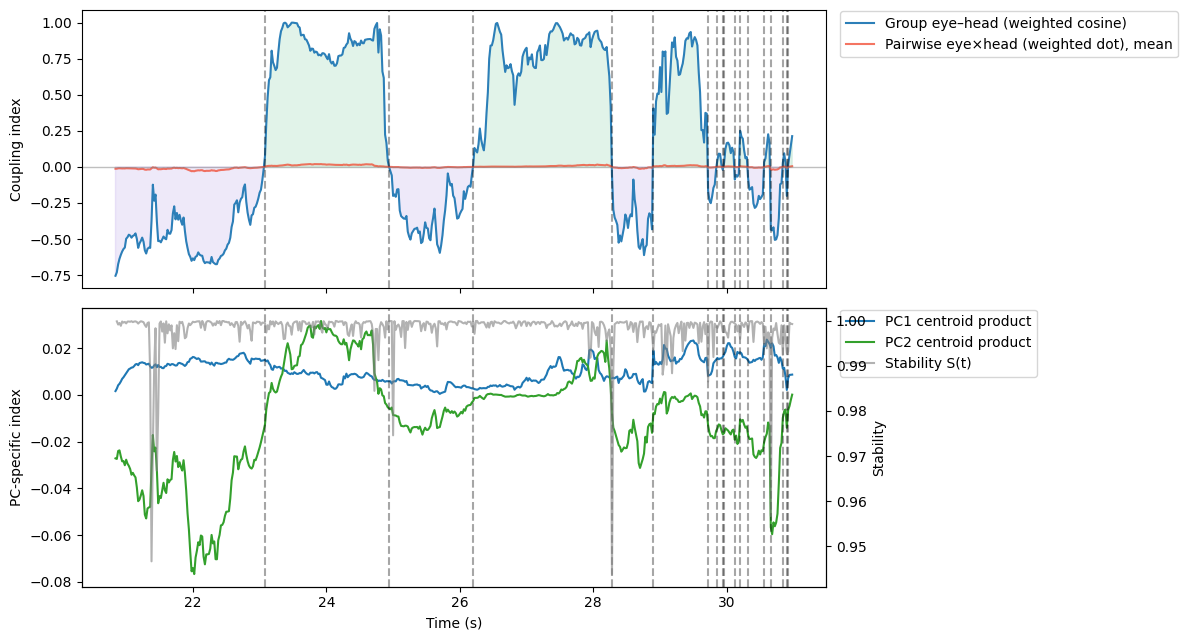

In [24]:
# ==============================================
# Eye–Head coupling metrics for PC1 & PC2 only
# ==============================================
# This cell computes time-varying coupling indices between eye and head
# variables using PC1/PC2 loadings, detects regime boundaries, and plots
# the results. It respects `smoothing` if enabled earlier.

_target_pcs = ['PC1', 'PC2']
loading_col = 'loading_smooth' if globals().get('smoothing', False) and 'loading_smooth' in components_long_vis.columns else 'loading'

# Keep only PC1/PC2 rows and build a tidy wide table per Time×Features with PC1,PC2
_df = (
    components_long_vis[components_long_vis['PC'].isin(_target_pcs)]
    .copy()
)
_df['group'] = _df['Features'].apply(_feature_group_from_name)

_pivot = (
    _df.pivot_table(index=['Time', 'Features', 'group'], columns='PC', values=loading_col, aggfunc='mean')
        .reset_index()
        .sort_values(['Time', 'Features'])
)
for _pc in _target_pcs:
    if _pc not in _pivot.columns:
        _pivot[_pc] = np.nan

# Variance weights per time for PC1/PC2 (fallback to equal if unavailable)
if var_long is not None:
    _w = (
        var_long[var_long['PC'].isin(_target_pcs)]
        .pivot_table(index='Time', columns='PC', values='explained_variance_ratio', aggfunc='mean')
        .sort_index()
    )
else:
    _w = None

# ---- Helper to fetch 2D weight vector per time ----
_def_equal_w = np.array([0.5, 0.5], dtype=float)

def _weights_for_time(t: float) -> np.ndarray:
    if _w is None:
        return _def_equal_w
    if t in _w.index:
        wrow = _w.loc[t, _target_pcs].to_numpy(dtype=float)
    else:
        # nearest weight if exact time not present
        idx = np.searchsorted(_w.index.values, t)
        idx = np.clip(idx, 0, len(_w.index.values)-1)
        wrow = _w.iloc[idx][_target_pcs].to_numpy(dtype=float)
    if not np.isfinite(wrow).all() or wrow.sum() <= 0:
        return _def_equal_w
    return wrow

# ---- Compute coupling indices per time ----
_coupling_rows = []
for t, g in _pivot.groupby('Time', sort=True):
    eye = g[g['group'] == 'Eye'][_target_pcs]
    head = g[g['group'] == 'Head'][_target_pcs]
    if eye.empty or head.empty:
        _coupling_rows.append({'Time': t, 'C_pair_mean': np.nan, 'C_EH': np.nan, 'C1': np.nan, 'C2': np.nan})
        continue
    w = _weights_for_time(t)
    # Group centroids in PC space
    eye_vec = eye.mean().to_numpy(dtype=float)   # [PC1, PC2]
    head_vec = head.mean().to_numpy(dtype=float)
    # Signed, variance-weighted cosine similarity between group centroids
    num = np.dot(eye_vec * w, head_vec)
    denom = np.linalg.norm(eye_vec * np.sqrt(w)) * np.linalg.norm(head_vec * np.sqrt(w))
    C_EH = num / denom if denom > 0 else np.nan
    # Pairwise, variance-weighted dot product averaged across all eye×head pairs
    E = eye.to_numpy(dtype=float)
    H = head.to_numpy(dtype=float)
    # Use outer products to combine all eye×head combinations (handles unequal counts)
    pair_mat = np.outer(E[:, 0], H[:, 0]) * w[0] + np.outer(E[:, 1], H[:, 1]) * w[1]
    C_pair_mean = float(np.nanmean(pair_mat))
    # PC-specific signed indices (centroid products)
    C1 = float(eye_vec[0] * head_vec[0])
    C2 = float(eye_vec[1] * head_vec[1])
    _coupling_rows.append({'Time': t, 'C_pair_mean': C_pair_mean, 'C_EH': C_EH, 'C1': C1, 'C2': C2})

coupling_df = pd.DataFrame(_coupling_rows).sort_values('Time')

# ---- Stability S(t): cosine similarity of PC loading patterns across adjacent times ----
# Restrict to Eye+Head features for stability of relevant coupling
EH = _pivot[_pivot['group'].isin(['Eye', 'Head'])]
feat_order = (
    EH.groupby('Features')
      .size()
      .sort_values(ascending=False)
      .index.tolist()
)
# Matrices Time×Features for PC1 and PC2
M1 = EH.pivot_table(index='Time', columns='Features', values='PC1', aggfunc='mean').reindex(columns=feat_order).sort_index()
M2 = EH.pivot_table(index='Time', columns='Features', values='PC2', aggfunc='mean').reindex(columns=feat_order).sort_index()

def _row_cos(a_prev: np.ndarray, a_cur: np.ndarray) -> float:
    denom = np.linalg.norm(a_prev) * np.linalg.norm(a_cur)
    if denom <= 0:
        return np.nan
    return float(np.dot(a_prev, a_cur) / denom)

S1 = [np.nan]
S2 = [np.nan]
_times = M1.index.to_numpy()
for i in range(1, len(_times)):
    S1.append(_row_cos(M1.iloc[i-1].to_numpy(dtype=float), M1.iloc[i].to_numpy(dtype=float)))
    S2.append(_row_cos(M2.iloc[i-1].to_numpy(dtype=float), M2.iloc[i].to_numpy(dtype=float)))

stability_df = pd.DataFrame({'Time': _times, 'S1': S1, 'S2': S2})
if _w is not None:
    w_aligned = _w.reindex(stability_df['Time']).reset_index(drop=True).fillna(0.0)
    S_weighted = (w_aligned['PC1'].to_numpy()*stability_df['S1'] + w_aligned['PC2'].to_numpy()*stability_df['S2']) / (w_aligned['PC1'] + w_aligned['PC2']).replace(0, np.nan)
    var_sum = (w_aligned['PC1'] + w_aligned['PC2']).to_numpy()
else:
    S_weighted = (np.array(stability_df['S1']) + np.array(stability_df['S2'])) / 2.0
    var_sum = np.full(len(stability_df), np.nan)

stability_df['S'] = S_weighted
stability_df['var12'] = var_sum

# ---- Regime boundaries ----
# 1) Zero-crossings of the signed group index
sign_cross_idx = np.where(np.sign(coupling_df['C_EH']).diff().fillna(0).abs() > 0)[0]
# 2) Large changes with low stability and adequate variance
dC = np.gradient(coupling_df['C_EH'].to_numpy(dtype=float))
abs_dC = np.abs(dC)
local_max_mask = (abs_dC[1:-1] > abs_dC[:-2]) & (abs_dC[1:-1] > abs_dC[2:])
local_max_idx = (np.where(local_max_mask)[0] + 1)
# thresholds
S_thresh = np.nanquantile(stability_df['S'], 0.2)
var_floor = 0.3 if np.isfinite(stability_df['var12']).any() else -np.inf
selected_idx = []
for i in local_max_idx:
    t = coupling_df['Time'].iloc[i]
    # lookup stability/variance at nearest index
    j = np.searchsorted(stability_df['Time'].to_numpy(), t)
    j = np.clip(j, 0, len(stability_df)-1)
    if (np.isnan(S_thresh) or stability_df['S'].iloc[j] <= S_thresh) and (np.isfinite(stability_df['var12'].iloc[j]) is False or stability_df['var12'].iloc[j] >= var_floor):
        selected_idx.append(i)

boundary_idx = sorted(set(sign_cross_idx.tolist() + selected_idx))
boundary_times = coupling_df['Time'].iloc[boundary_idx].to_numpy()

# ---- Plot: coupling indices and regime boundaries ----
fig, ax = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)

# Panel 1: Signed group coupling and pairwise mean
ax[0].plot(coupling_df['Time'], coupling_df['C_EH'], color='#2c7fb8', label='Group eye–head (weighted cosine)')
ax[0].plot(coupling_df['Time'], coupling_df['C_pair_mean'], color='#f03b20', alpha=0.7, label='Pairwise eye×head (weighted dot), mean')
# Shade synergy vs anti-coupling
t_vals = coupling_df['Time'].to_numpy()
vals = coupling_df['C_EH'].to_numpy()
ax[0].fill_between(t_vals, 0, vals, where=(vals>=0), color='#3cb371', alpha=0.15, interpolate=True)
ax[0].fill_between(t_vals, 0, vals, where=(vals<0), color='#9370db', alpha=0.15, interpolate=True)
for t in boundary_times:
    ax[0].axvline(t, color='k', linestyle='--', alpha=0.35)
ax[0].axhline(0, color='gray', linewidth=1, alpha=0.5)
ax[0].set_ylabel('Coupling index')
ax[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1.02))

# Panel 2: PC-specific indices and stability
ax[1].plot(coupling_df['Time'], coupling_df['C1'], color='#1f78b4', label='PC1 centroid product')
ax[1].plot(coupling_df['Time'], coupling_df['C2'], color='#33a02c', label='PC2 centroid product')
ax2 = ax[1].twinx()
ax2.plot(stability_df['Time'], stability_df['S'], color='gray', alpha=0.6, label='Stability S(t)')
for t in boundary_times:
    ax[1].axvline(t, color='k', linestyle='--', alpha=0.35)
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('PC-specific index')
ax2.set_ylabel('Stability')
# Build a combined legend
lines_1, labels_1 = ax[1].get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax[1].legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', bbox_to_anchor=(1.01, 1.02))

plt.tight_layout()
plt.show()

# Expose boundary times for reuse elsewhere (e.g., to overlay on other plots)
regime_boundary_times = boundary_times.tolist()



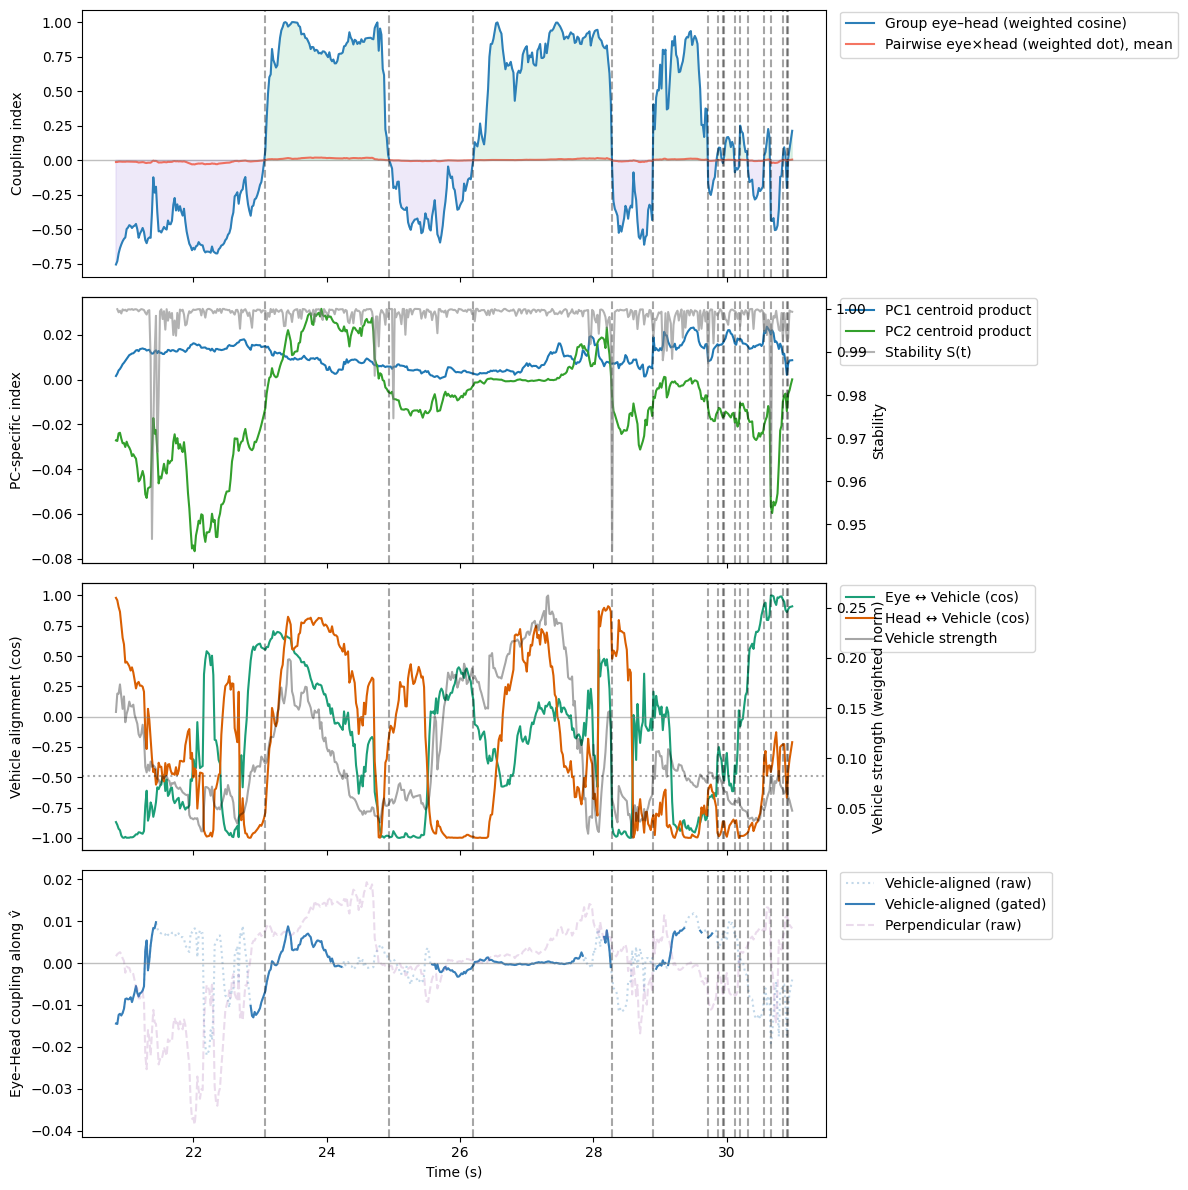

In [29]:
# ======================================================
# Vehicle-context metrics: alignment to Car/Steering axis
# ======================================================
# Build vehicle centroid V(t) from features containing 'car' or 'steer'

veh_keywords = ['car', 'steer']
veh_mask = _pivot['Features'].str.lower().apply(lambda s: any(k in s for k in veh_keywords))

veh_rows = []
for t, g in _pivot.groupby('Time', sort=True):
    w = _weights_for_time(t)
    ws = np.sqrt(w)
    g_eye = g[g['group'] == 'Eye'][_target_pcs]
    g_head = g[g['group'] == 'Head'][_target_pcs]
    g_veh = g[veh_mask.loc[g.index]][_target_pcs]
    if g_eye.empty or g_head.empty or g_veh.empty:
        veh_rows.append({'Time': t, 'C_E_to_V': np.nan, 'C_H_to_V': np.nan, 'C_rel': np.nan, 'V_strength': np.nan,
                         'e_par': np.nan, 'h_par': np.nan, 'e_perp': np.nan, 'h_perp': np.nan,
                         'C_along': np.nan, 'C_perp': np.nan})
        continue
    E = g_eye.mean().to_numpy(dtype=float)
    H = g_head.mean().to_numpy(dtype=float)
    V = g_veh.mean().to_numpy(dtype=float)
    # Weighted vectors in whitened space
    Ew = E * ws
    Hw = H * ws
    Vw = V * ws
    Vn = np.linalg.norm(Vw)

    # Variance-weighted cosines (clip for numerical stability)
    def _wcos(a: np.ndarray, b: np.ndarray, w: np.ndarray) -> float:
        num = float(np.dot(a * w, b))
        denom = float(np.linalg.norm(a * np.sqrt(w)) * np.linalg.norm(b * np.sqrt(w)))
        if denom <= 0:
            return np.nan
        val = num / denom
        return float(np.clip(val, -1.0, 1.0))

    CEv = _wcos(E, V, w)
    CHv = _wcos(H, V, w)

    if Vn <= 1e-9:
        e_par = h_par = e_perp = h_perp = np.nan
        C_along = C_perp = np.nan
        V_strength = 0.0
    else:
        vhat = Vw / Vn
        vperp = np.array([-vhat[1], vhat[0]])
        e_par = float(np.dot(Ew, vhat))
        h_par = float(np.dot(Hw, vhat))
        e_perp = float(np.dot(Ew, vperp))
        h_perp = float(np.dot(Hw, vperp))
        C_along = float(e_par * h_par)
        C_perp = float(e_perp * h_perp)
        V_strength = float(Vn)

    veh_rows.append({'Time': t, 'C_E_to_V': CEv, 'C_H_to_V': CHv, 'C_rel': CEv - CHv, 'V_strength': V_strength,
                     'e_par': e_par, 'h_par': h_par, 'e_perp': e_perp, 'h_perp': h_perp,
                     'C_along': C_along, 'C_perp': C_perp})

veh_df = pd.DataFrame(veh_rows).sort_values('Time')

# Masking by vehicle strength
vehicle_strength_quantile = float(globals().get('vehicle_strength_quantile', 0.5))  # 0..1
vehicle_strength_floor = float(globals().get('vehicle_strength_floor', 0.05))
thr = np.nanquantile(veh_df['V_strength'], vehicle_strength_quantile) if veh_df['V_strength'].notna().any() else vehicle_strength_floor
thr = max(thr, vehicle_strength_floor)
veh_df['veh_active'] = veh_df['V_strength'] >= thr
veh_df['C_along_masked'] = veh_df['C_along'].where(veh_df['veh_active'])

# Merge with prior coupling_df (idempotent): drop existing vehicle-context cols before merging
_cols_new = ['C_E_to_V','C_H_to_V','C_rel','V_strength','e_par','h_par','e_perp','h_perp','C_along','C_perp','veh_active','C_along_masked']
existing_cols = [c for c in _cols_new if c in coupling_df.columns]
if len(existing_cols) > 0:
    coupling_df = coupling_df.drop(columns=existing_cols)
# Merge only the necessary columns to avoid accidental duplicates
coupling_df = coupling_df.merge(veh_df[['Time'] + _cols_new], on='Time', how='left')

# ------------- Visualization with vehicle context -------------
fig, ax = plt.subplots(4, 1, figsize=(12, 12.0), sharex=True)

# Panel 1: Group/pairwise coupling as before
ax[0].plot(coupling_df['Time'], coupling_df['C_EH'], color='#2c7fb8', label='Group eye–head (weighted cosine)')
ax[0].plot(coupling_df['Time'], coupling_df['C_pair_mean'], color='#f03b20', alpha=0.7, label='Pairwise eye×head (weighted dot), mean')
# Shade synergy vs anti-coupling
_t = coupling_df['Time'].to_numpy()
_vals = coupling_df['C_EH'].to_numpy()
ax[0].fill_between(_t, 0, _vals, where=(_vals>=0), color='#3cb371', alpha=0.15, interpolate=True)
ax[0].fill_between(_t, 0, _vals, where=(_vals<0), color='#9370db', alpha=0.15, interpolate=True)
for t in regime_boundary_times:
    ax[0].axvline(t, color='k', linestyle='--', alpha=0.35)
ax[0].axhline(0, color='gray', linewidth=1, alpha=0.5)
ax[0].set_ylabel('Coupling index')
ax[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1.02))

# Panel 2: PC-specific indices and stability
ax[1].plot(coupling_df['Time'], coupling_df['C1'], color='#1f78b4', label='PC1 centroid product')
ax[1].plot(coupling_df['Time'], coupling_df['C2'], color='#33a02c', label='PC2 centroid product')
ax21 = ax[1].twinx()
ax21.plot(stability_df['Time'], stability_df['S'], color='gray', alpha=0.6, label='Stability S(t)')
for t in regime_boundary_times:
    ax[1].axvline(t, color='k', linestyle='--', alpha=0.35)
ax[1].set_ylabel('PC-specific index')
ax21.set_ylabel('Stability')
lines_1, labels_1 = ax[1].get_legend_handles_labels()
lines_2, labels_2 = ax21.get_legend_handles_labels()
ax[1].legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', bbox_to_anchor=(1.01, 1.02))

# Panel 3: Alignment to vehicle and vehicle strength
ax[2].plot(coupling_df['Time'], coupling_df['C_E_to_V'], color='#1b9e77', label='Eye ↔ Vehicle (cos)')
ax[2].plot(coupling_df['Time'], coupling_df['C_H_to_V'], color='#d95f02', label='Head ↔ Vehicle (cos)')
ax22 = ax[2].twinx()
ax22.plot(coupling_df['Time'], coupling_df['V_strength'], color='black', alpha=0.35, label='Vehicle strength')
ax22.axhline(thr, color='black', linestyle=':', alpha=0.35)
for t in regime_boundary_times:
    ax[2].axvline(t, color='k', linestyle='--', alpha=0.35)
ax[2].axhline(0, color='gray', linewidth=1, alpha=0.5)
ax[2].set_ylabel('Vehicle alignment (cos)')
ax22.set_ylabel('Vehicle strength (weighted norm)')
lines_3, labels_3 = ax[2].get_legend_handles_labels()
lines_4, labels_4 = ax22.get_legend_handles_labels()
ax[2].legend(lines_3 + lines_4, labels_3 + labels_4, loc='upper left', bbox_to_anchor=(1.01, 1.02))

# Panel 4: Single vehicle-aligned eye–head coupling metric (gated)
ax[3].plot(coupling_df['Time'], coupling_df['C_along'], color='#377eb8', alpha=0.3, linestyle=':', label='Vehicle-aligned (raw)')
ax[3].plot(coupling_df['Time'], coupling_df['C_along_masked'], color='#377eb8', label='Vehicle-aligned (gated)')
# Optional: show perpendicular component faintly for context
ax[3].plot(coupling_df['Time'], coupling_df['C_perp'], color='#984ea3', alpha=0.2, linestyle='--', label='Perpendicular (raw)')
for t in regime_boundary_times:
    ax[3].axvline(t, color='k', linestyle='--', alpha=0.35)
ax[3].axhline(0, color='gray', linewidth=1, alpha=0.5)
ax[3].set_xlabel('Time (s)')
ax[3].set_ylabel('Eye–Head coupling along v̂')
ax[3].legend(loc='upper left', bbox_to_anchor=(1.01, 1.02))

plt.tight_layout()
plt.show()
